# This is a file used to train a light weigt CNN to classify whether a component leg is plugged into the breadboard socket


In [1]:
!git clone 'https://github.com/AlexMIaoPU/remote-lab.git'

Cloning into 'remote-lab'...
remote: Enumerating objects: 857, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 857 (delta 0), reused 171 (delta 0), pack-reused 681 (from 1)
Receiving objects: 100% (857/857), 131.51 MiB | 30.79 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [2]:
!mv -v ./remote-lab/[!.]* ./

renamed './remote-lab/bb2.jpg' -> './bb2.jpg'
renamed './remote-lab/bb3.jpg' -> './bb3.jpg'
renamed './remote-lab/bb4.jpg' -> './bb4.jpg'
renamed './remote-lab/bb5.jpg' -> './bb5.jpg'
renamed './remote-lab/breadboard.jpg' -> './breadboard.jpg'
renamed './remote-lab/Classifier.py' -> './Classifier.py'
renamed './remote-lab/Colour_band_detection.ipynb' -> './Colour_band_detection.ipynb'
renamed './remote-lab/Copy_of_Detectron2_Tutorial.ipynb' -> './Copy_of_Detectron2_Tutorial.ipynb'
renamed './remote-lab/dataset' -> './dataset'
renamed './remote-lab/extracted_images' -> './extracted_images'
renamed './remote-lab/gird_extract.ipynb' -> './gird_extract.ipynb'
renamed './remote-lab/LossEvalHook.py' -> './LossEvalHook.py'
renamed './remote-lab/Mask.py' -> './Mask.py'
renamed './remote-lab/plug_data' -> './plug_data'
renamed './remote-lab/Processing.py' -> './Processing.py'
renamed './remote-lab/README.md' -> './README.md'
renamed './remote-lab/Resistor_pipeline.ipynb' -> './Resistor_pipeline

## Setup

In [3]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [4]:
# === CONFIG ===
data_dir = "./plug_data"  # Folder with `plugged/` and `not_plugged/`
num_classes = 2
batch_size = 32
num_epochs = 10
learning_rate = 1e-4
input_size = 224  # MobilenetV2 expects 224x224 input


In [23]:
# === DATA AUGMENTATION ===
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # normalize grayscale to [-1, 1]
    ]),
    'val': transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]),
    'infer': transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
}

In [6]:
# === DATA LOADING ===
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val']
}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [7]:
# === MODEL ===
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

# === LOSS & OPTIMIZER ===
# Prioritize True Positives on class 1 (plugged)
class_weights = torch.tensor([1.0, 8.0], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 82.7MB/s]


In [8]:
# === TRAINING LOOP ===
def train_model(model, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'val':
                print(confusion_matrix(all_labels, all_preds))
                print(classification_report(all_labels, all_preds, target_names=class_names))

    return model

# Visualisation

In [28]:
# === VISUAL VALIDATION ===
def visualize_predictions(model, dataset, num_images=6):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(12, 6))

    for i in range(num_images):
        idx = random.randint(0, len(dataset) - 1)
        image, label = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

        image_np = image.permute(1, 2, 0).cpu().numpy()
        image_np = (image_np * 0.5 + 0.5).clip(0, 1)  # denormalize

        plt.subplot(2, 3, i+1)
        plt.imshow(image_np, cmap='gray')
        plt.title(f"GT: {class_names[label]}\nPred: {class_names[pred.item()]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# === INFERENCE ON UNSEEN DATA ===
def classify_single_image(model, image_path):
    model.eval()
    image = Image.open(image_path)
    transform = data_transforms['infer']
    input_tensor = transform(image).unsqueeze(0).to(device)
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    _, pred = torch.max(output, 1)
    return class_names[pred.item()], probs.squeeze().cpu().detach().numpy()

## Training and Save

In [10]:
# === TRAIN ===
model = train_model(model, criterion, optimizer, num_epochs=num_epochs)

Epoch 1/10
--------------------
Train Loss: 0.6033 Acc: 0.6724
Val Loss: 0.8810 Acc: 0.8214
[[69  0]
 [15  0]]
              precision    recall  f1-score   support

 not_plugged       0.82      1.00      0.90        69
     plugged       0.00      0.00      0.00        15

    accuracy                           0.82        84
   macro avg       0.41      0.50      0.45        84
weighted avg       0.67      0.82      0.74        84

Epoch 2/10
--------------------


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Train Loss: 0.3366 Acc: 0.8462
Val Loss: 0.7246 Acc: 0.8810
[[69  0]
 [10  5]]
              precision    recall  f1-score   support

 not_plugged       0.87      1.00      0.93        69
     plugged       1.00      0.33      0.50        15

    accuracy                           0.88        84
   macro avg       0.94      0.67      0.72        84
weighted avg       0.90      0.88      0.86        84

Epoch 3/10
--------------------
Train Loss: 0.1793 Acc: 0.9288
Val Loss: 0.3726 Acc: 0.9286
[[67  2]
 [ 4 11]]
              precision    recall  f1-score   support

 not_plugged       0.94      0.97      0.96        69
     plugged       0.85      0.73      0.79        15

    accuracy                           0.93        84
   macro avg       0.89      0.85      0.87        84
weighted avg       0.93      0.93      0.93        84

Epoch 4/10
--------------------
Train Loss: 0.1086 Acc: 0.9715
Val Loss: 0.2079 Acc: 0.9405
[[66  3]
 [ 2 13]]
              precision    recall  f1-score  

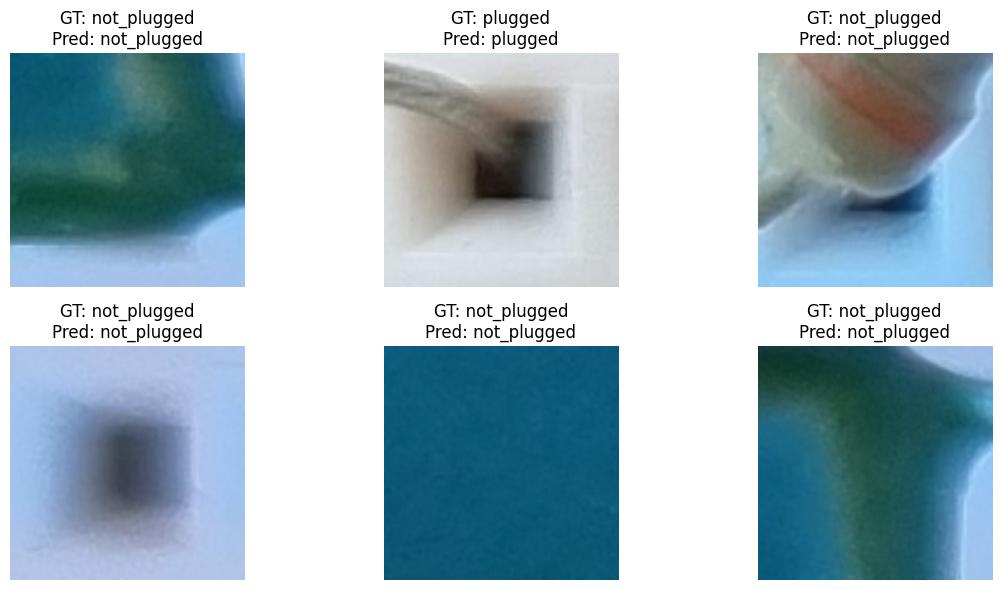

In [20]:
# === VISUALIZE ===
visualize_predictions(model, image_datasets['val'])

In [44]:
# === EXAMPLE USAGE ===
label, probabilities = classify_single_image(model, "./plug_data/test/.png")
print("Prediction:", label, "\nProbabilities:", probabilities)

Prediction: not_plugged 
Probabilities: [0.99512154 0.0048784 ]


In [45]:
# === SAVE ===
torch.save(model.state_dict(), "plug_classifier_mobilenet.pth")